# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Mean absolute error of the predicted number of...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,128,0.2150,2250.6716,3517.1775,1.8900,2.1816,0.9944,0.9966,0.0522,0.1029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,64,0.5393,2398.3816,3807.7207,3.1856,3.7224,0.9444,0.9691,0.1511,0.2437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


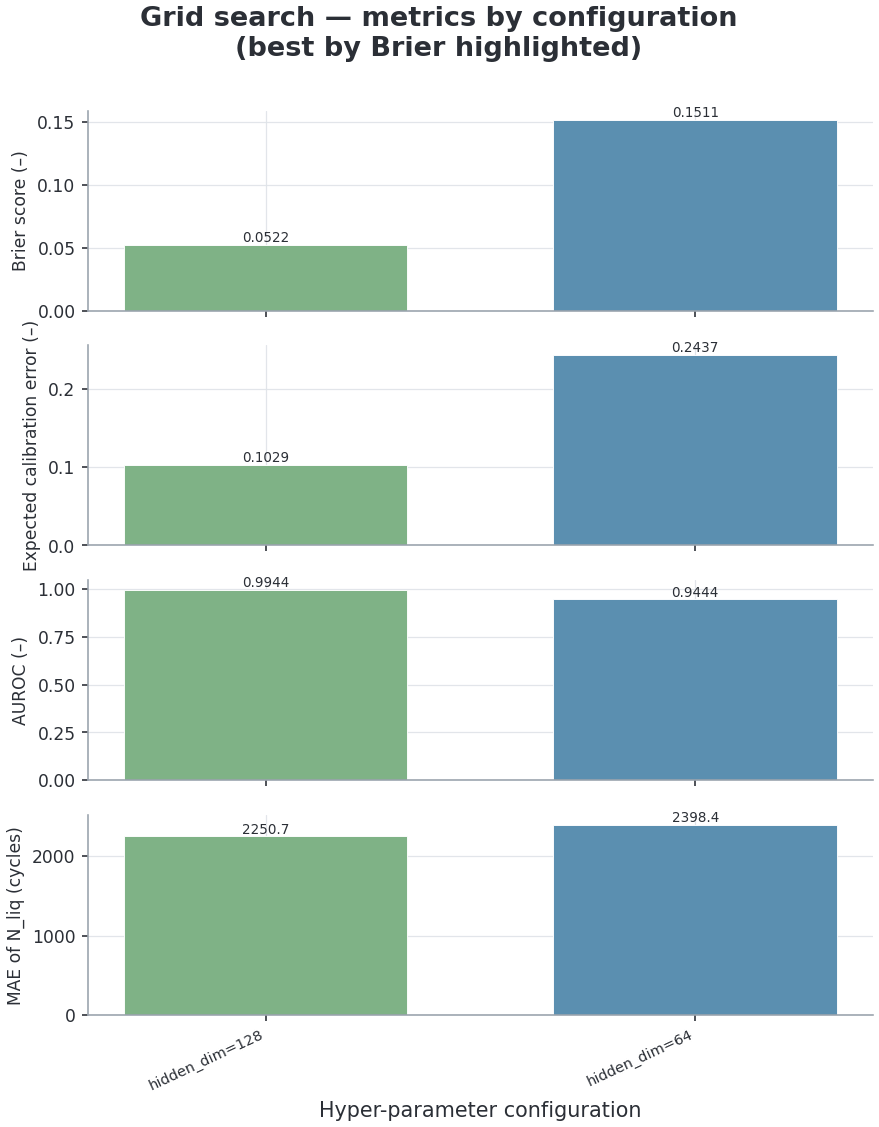

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,0.0972,2386.8281,3801.4238,2.7485,3.2512,0.9833,0.9917,0.2325,0.1405,...,2.0209,1.0,2.5938,1.0,3.0907,0.1167,0.7611,0.2347,NaN,0.0
1,64,0.2448,2385.4873,3800.2234,2.7209,3.2237,0.9829,0.9913,0.2208,0.2309,...,2.3860,1.0,3.0624,1.0,3.6491,0.1167,0.9174,0.2687,NaN,0.0


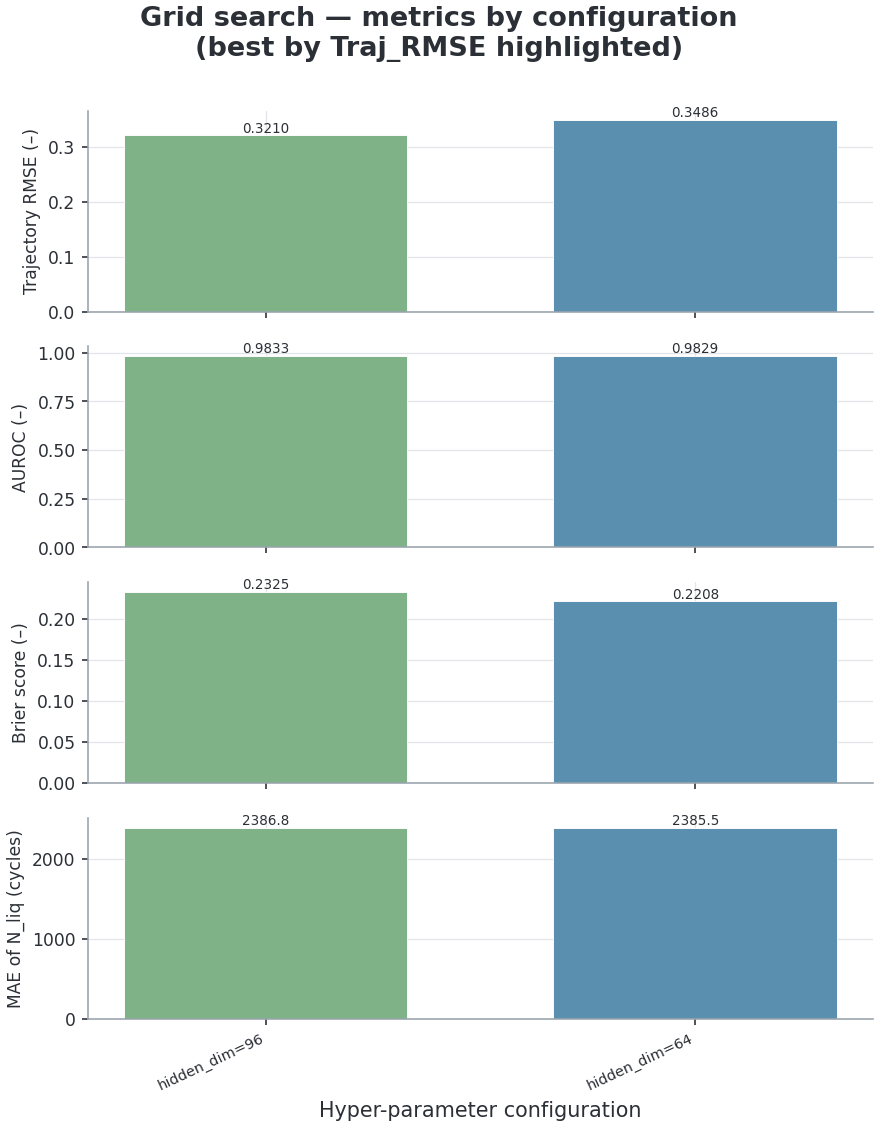

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,0.2213,2389.6709,3804.0476,2.8103,3.3156,0.8932,0.9181,0.2429,0.0865,...,2.2968,1.0,2.9478,1.0,3.5125,0.1167,0.8769,0.2572,NaN,0.0
1,64,0.2431,2386.3484,3801.2644,2.7378,3.2440,0.9885,0.9941,0.2445,0.1276,...,2.3461,1.0,3.0112,1.0,3.5880,0.1167,0.8986,0.2632,NaN,0.0


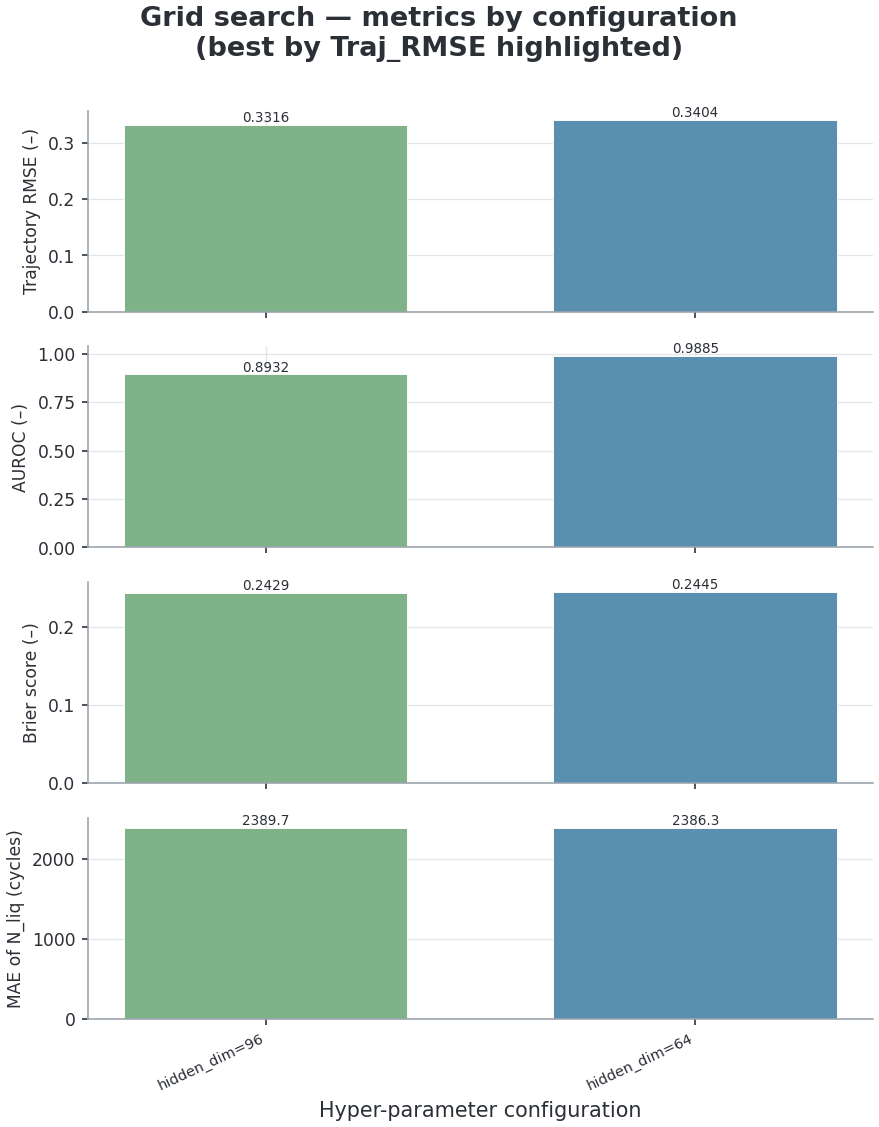

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,0.2715,2392.3860,3807.0032,2.8760,3.3925,0.9889,0.9940,0.2393,0.0851,...,2.4402,1.0,3.1319,1.0,3.7318,0.1167,0.9284,0.2665,NaN,0.0
1,64,0.2531,2394.1042,3808.8601,2.9213,3.4454,0.9679,0.9828,0.2470,0.2434,...,2.3548,1.0,3.0223,1.0,3.6012,0.1167,0.9037,0.2650,NaN,0.0


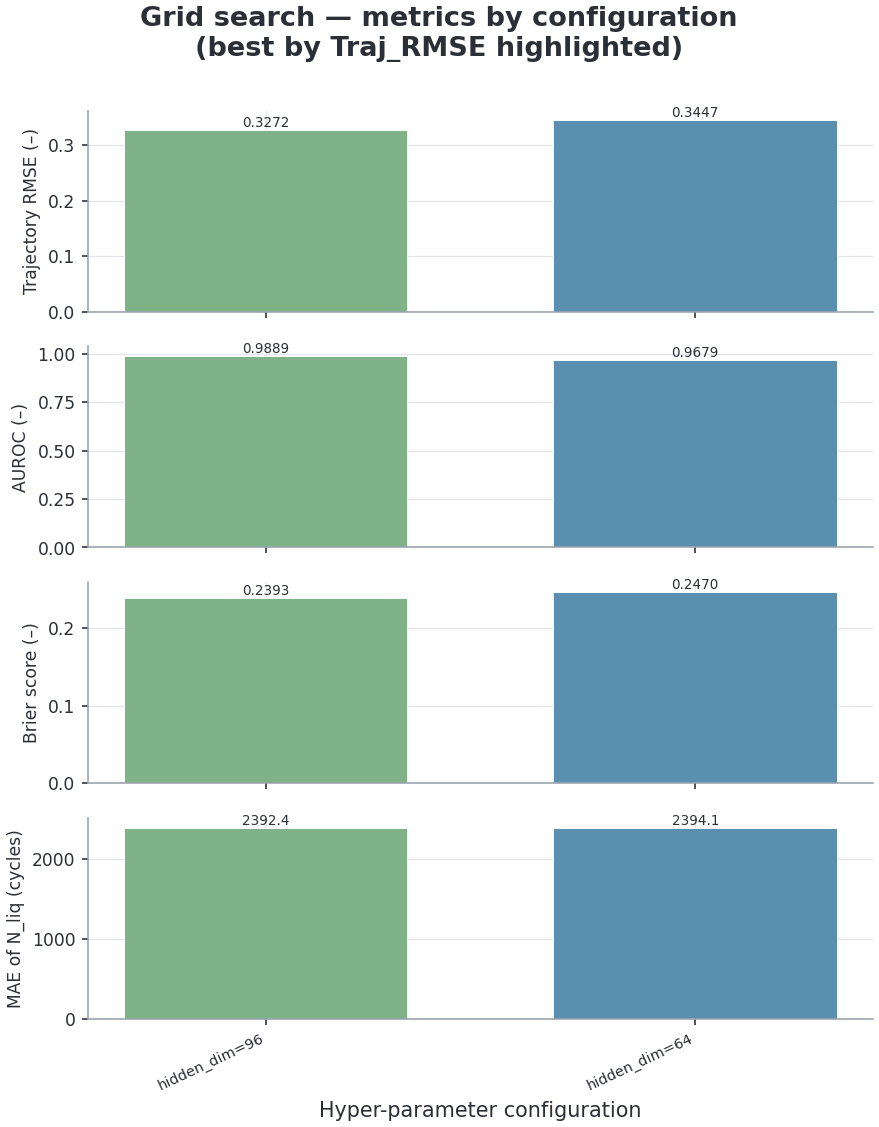

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,-0.6320,2295.2554,3700.8684,1.8012,2.2490,0.9846,0.9903,0.1736,0.2717,...,0.8418,1.0000,1.0804,1.0000,1.2874,0.0994,0.0889,0.1490,NaN,0.0
1,96,-0.4598,2349.8735,3755.6116,2.2636,2.7104,0.9919,0.9960,0.1014,0.2758,...,0.5783,0.7707,0.7422,0.8316,0.8844,0.1233,0.3120,0.1638,NaN,0.0


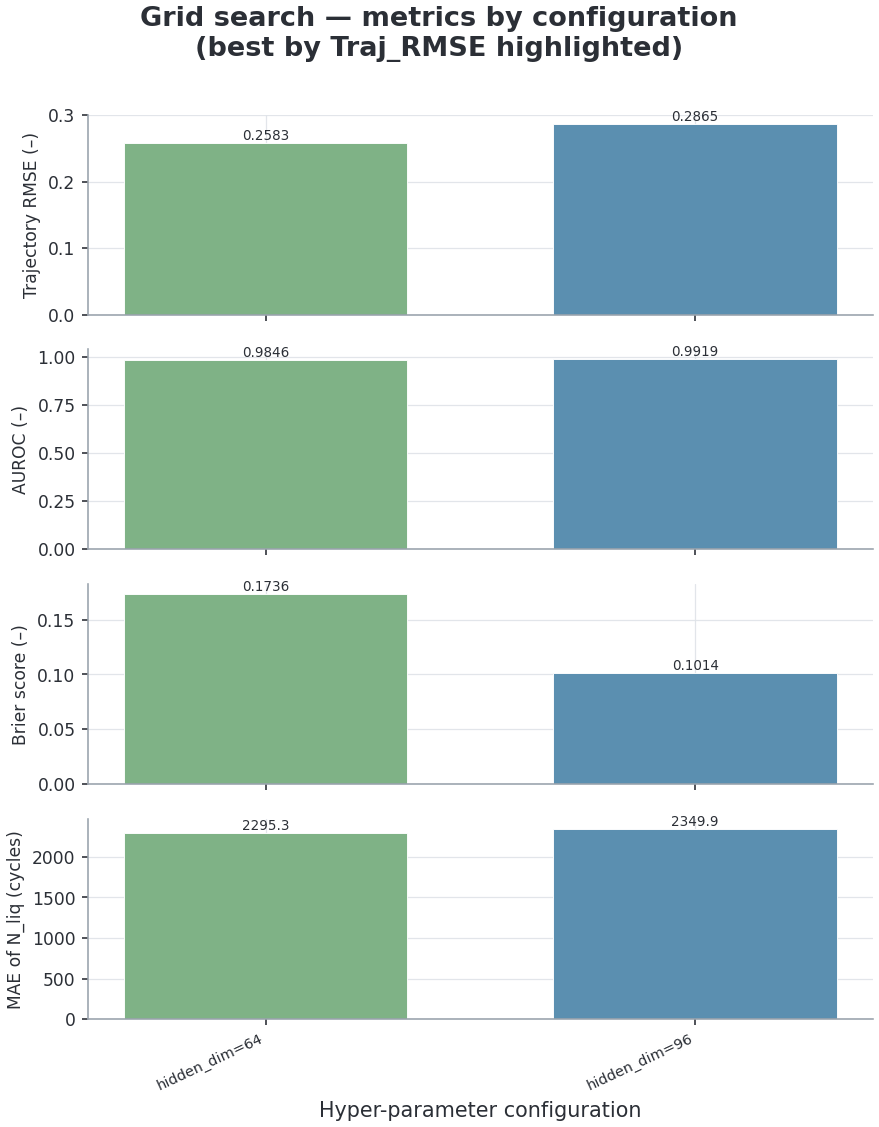

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,2,0.5933,2353.1704,3383.7856,2.1206,2.4034,0.9769,0.9841,0.1891,0.2413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,3,0.7341,2309.2568,3558.1040,2.0370,2.3452,0.9782,0.9868,0.2566,0.3213,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


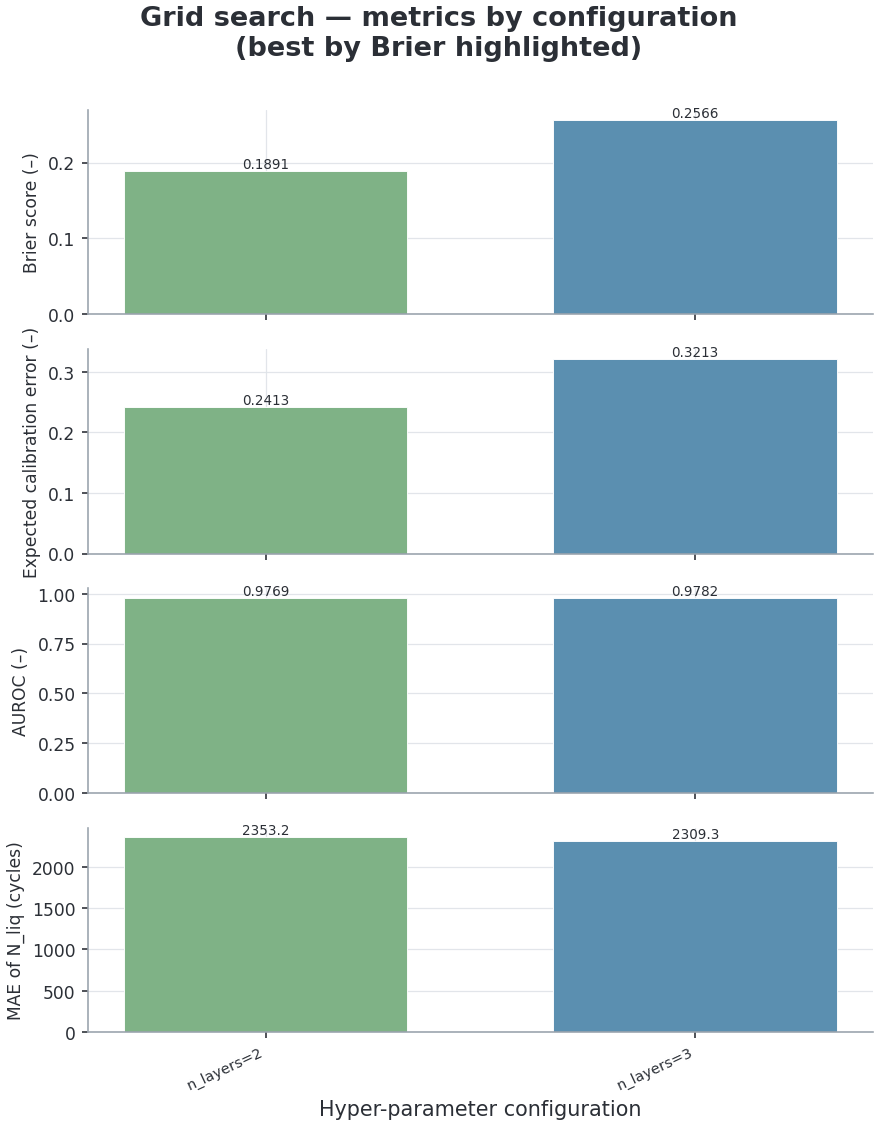

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,-0.5857,2360.0344,3778.2039,2.3739,2.8866,0.9009,0.9427,0.1873,0.2599,...,0.7176,0.9093,0.9210,0.9487,1.0974,0.0121,0.1147,0.1493,NaN,0.0
1,96,-0.5353,2309.5603,3702.2454,2.0324,2.4235,0.9739,0.9852,0.1702,0.2527,...,0.4771,0.7140,0.6124,0.7820,0.7297,0.1745,0.1874,0.1555,NaN,0.0


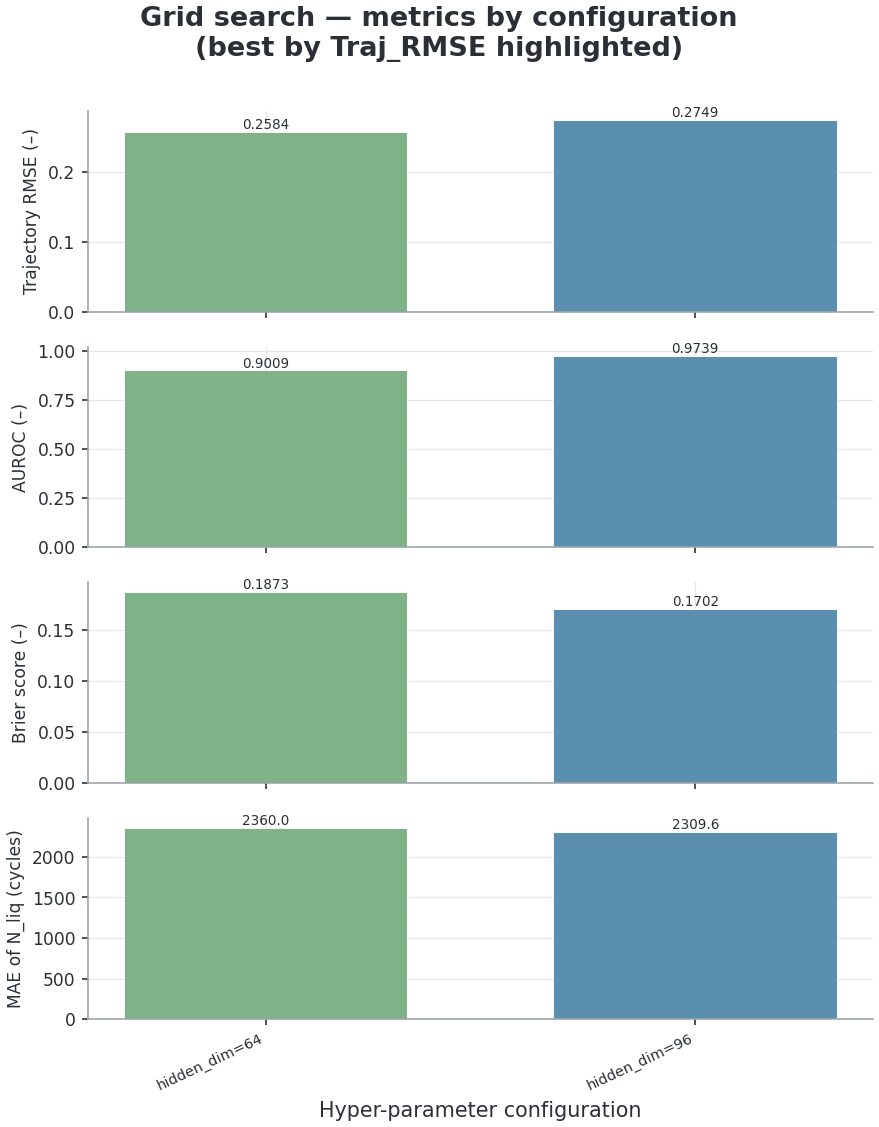

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,0.2303,2376.3691,3790.2200,2.5608,3.0466,0.9765,0.9874,0.2375,0.1197,...,2.2575,1.0,2.8974,1.0,3.4525,0.1167,0.8938,0.2751,NaN,0.0
1,96,0.1709,2384.5964,3799.0867,2.7004,3.1940,0.8590,0.8787,0.2427,0.1226,...,2.0647,1.0,2.6500,1.0,3.1577,0.1167,0.8285,0.2649,NaN,0.0


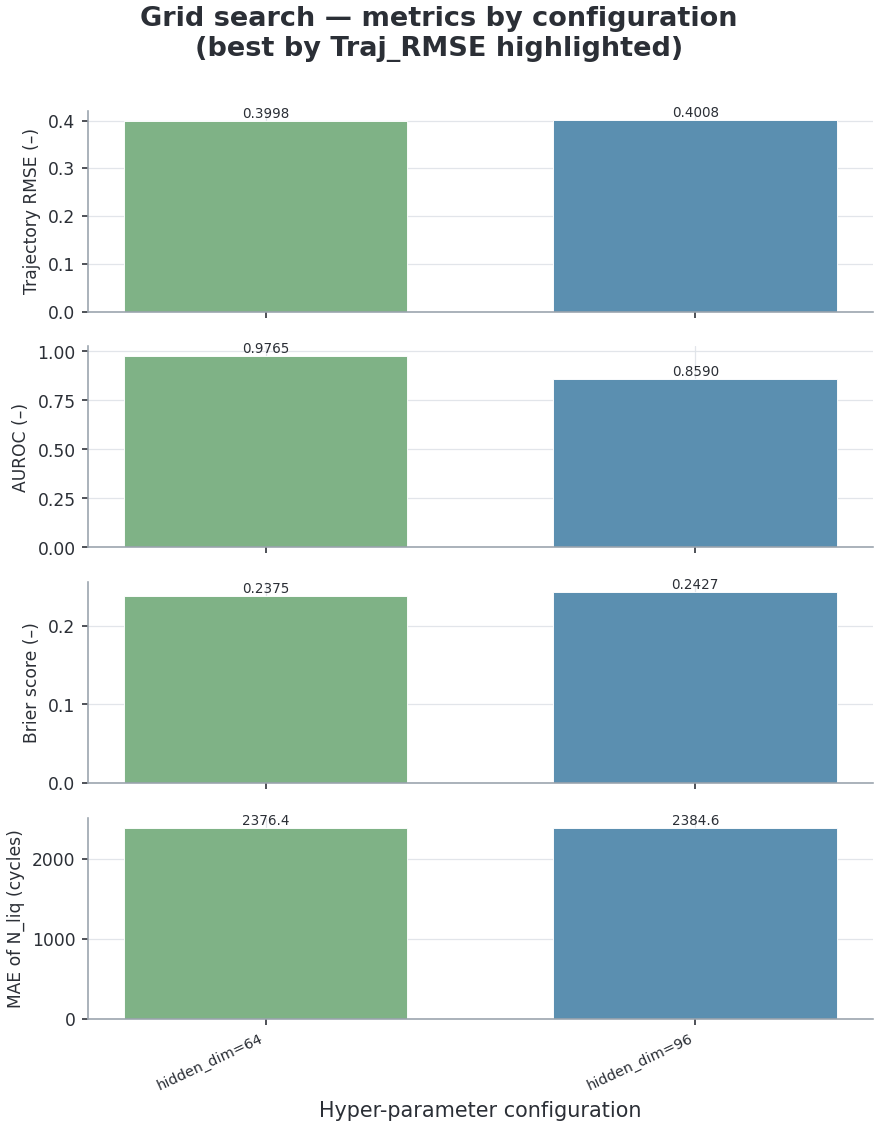

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 6}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,6,4.6825,2376.5508,3793.9666,2.5733,3.0987,0.8739,0.8982,0.2359,0.1547,...,0.5350,0.5702,0.6867,0.6783,0.8182,0.3107,0.6972,0.2094,NaN,0.0
1,4,5.6416,2393.2749,3807.9609,2.9008,3.4297,0.6359,0.7972,0.2469,0.1095,...,0.5303,0.5721,0.6807,0.6733,0.8111,0.3116,0.7273,0.2111,NaN,0.0


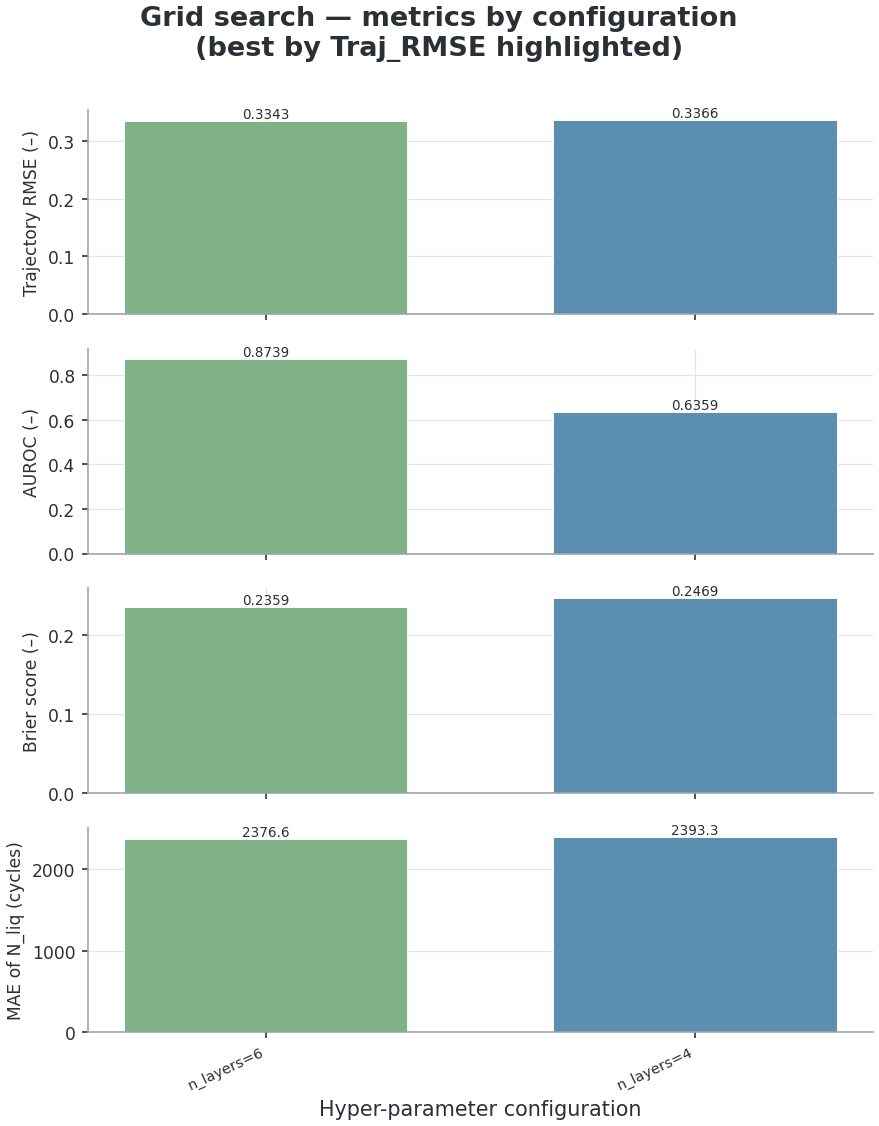

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 5}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,5,12.2051,2387.1946,3801.2163,2.7621,3.2582,0.9624,0.9749,0.2191,0.3333,...,0.5406,0.6171,0.6939,0.7476,0.8268,0.264,0.5371,0.1961,NaN,0.0
1,4,12.2525,2383.5591,3799.2500,2.6905,3.2035,0.9598,0.9735,0.2110,0.3323,...,0.5308,0.5790,0.6813,0.6951,0.8118,0.300,0.6216,0.2034,NaN,0.0


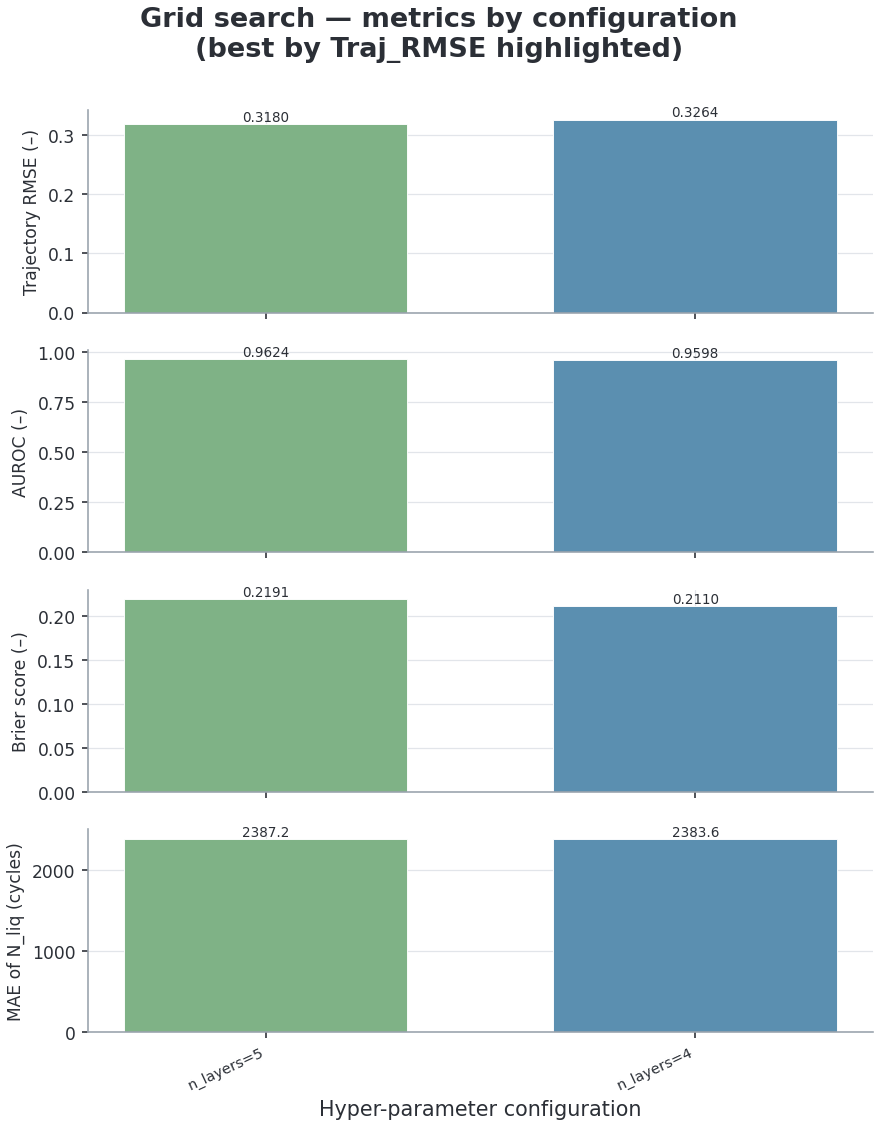

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=1, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.physics_epochs if name == "pinn" else config.baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": epochs, "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.5466 | валидация=0.1881 | val_AUROC=0.994


[MLP-Risk] эпоха 02 | обучение=0.1522 | валидация=0.0844 | val_AUROC=0.998


[MLP-Risk] эпоха 03 | обучение=0.0695 | валидация=0.0590 | val_AUROC=0.997


[MLP-Risk] эпоха 04 | обучение=0.0474 | валидация=0.0608 | val_AUROC=0.996


saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/mlp_risk


...

[Neural Spline Flow] эпоха 01 | обучение=13.0189 | валидация=12.2914 | val_AUROC=0.938 | val_RMSE=0.3182


[Neural Spline Flow] эпоха 02 | обучение=12.5170 | валидация=11.9846 | val_AUROC=0.989 | val_RMSE=0.3014


[Neural Spline Flow] эпоха 03 | обучение=12.3173 | валидация=11.7835 | val_AUROC=0.994 | val_RMSE=0.2830


[Neural Spline Flow] эпоха 04 | обучение=12.1307 | валидация=11.6879 | val_AUROC=0.996 | val_RMSE=0.2669


saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/nsf


## Кривые обучения с метриками

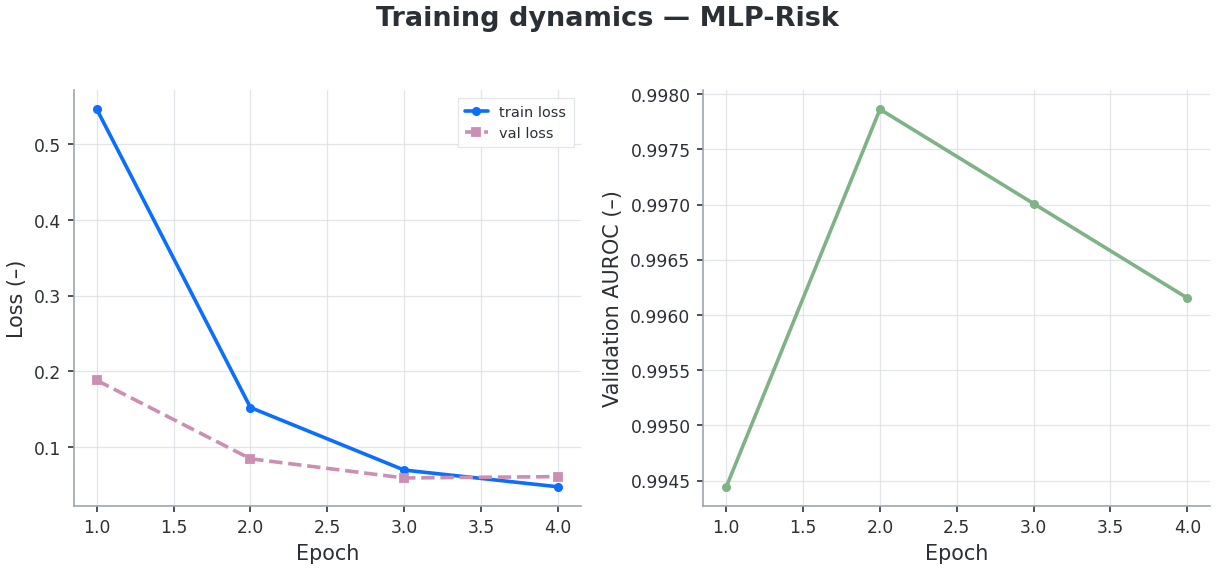

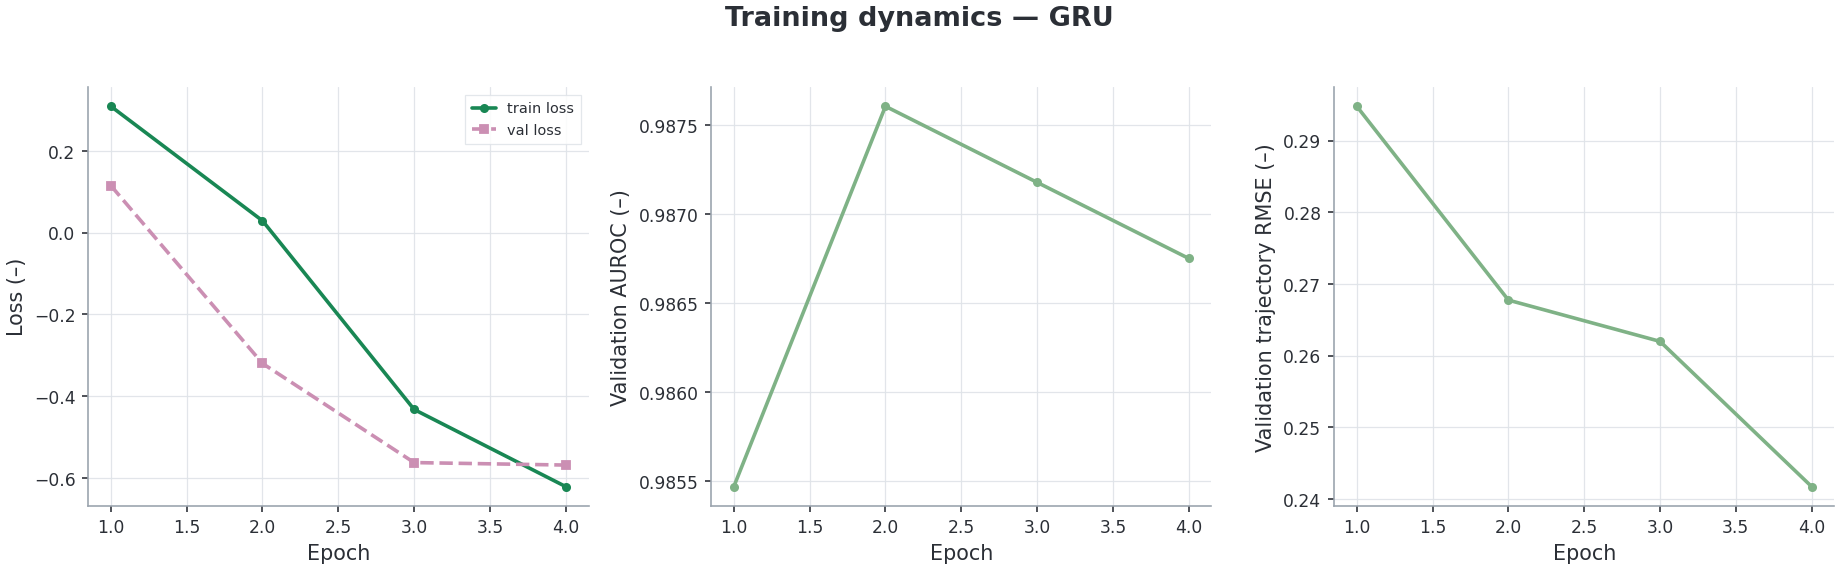

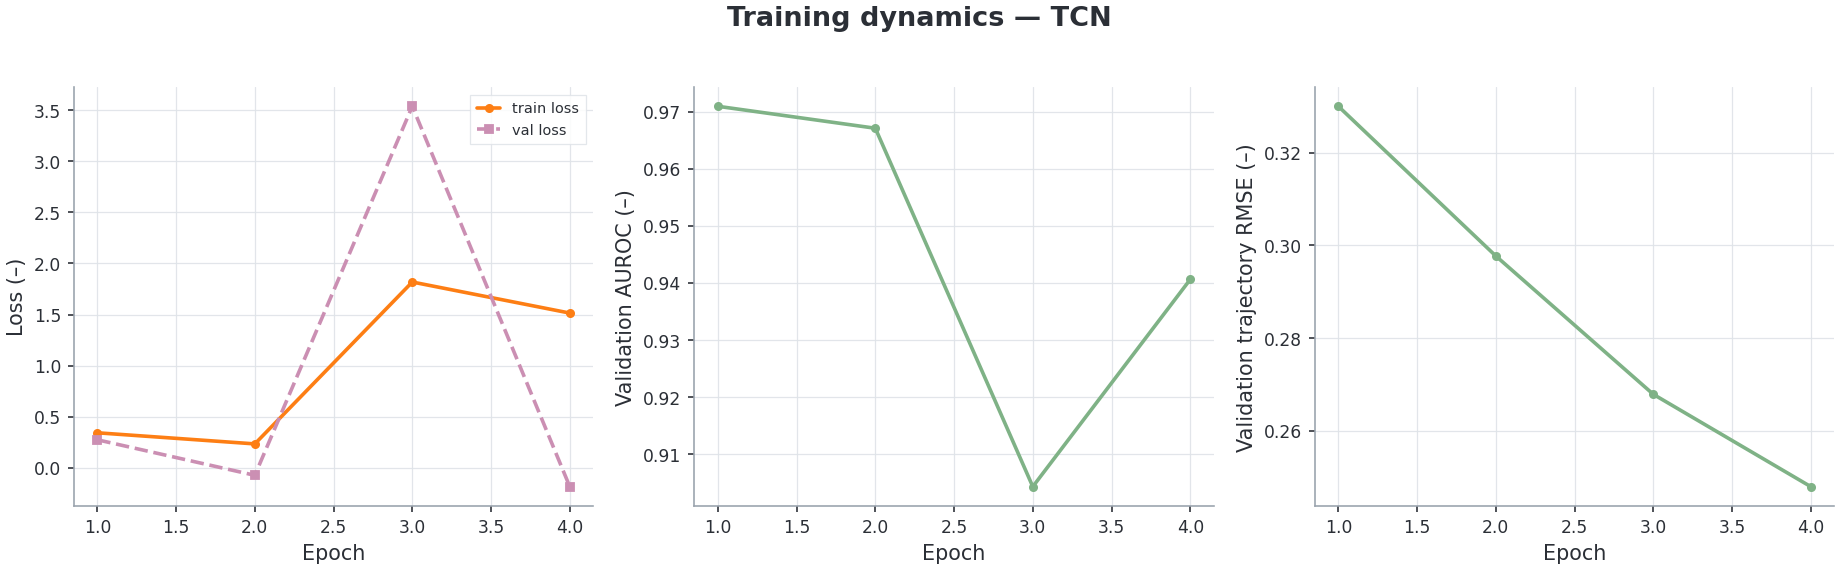

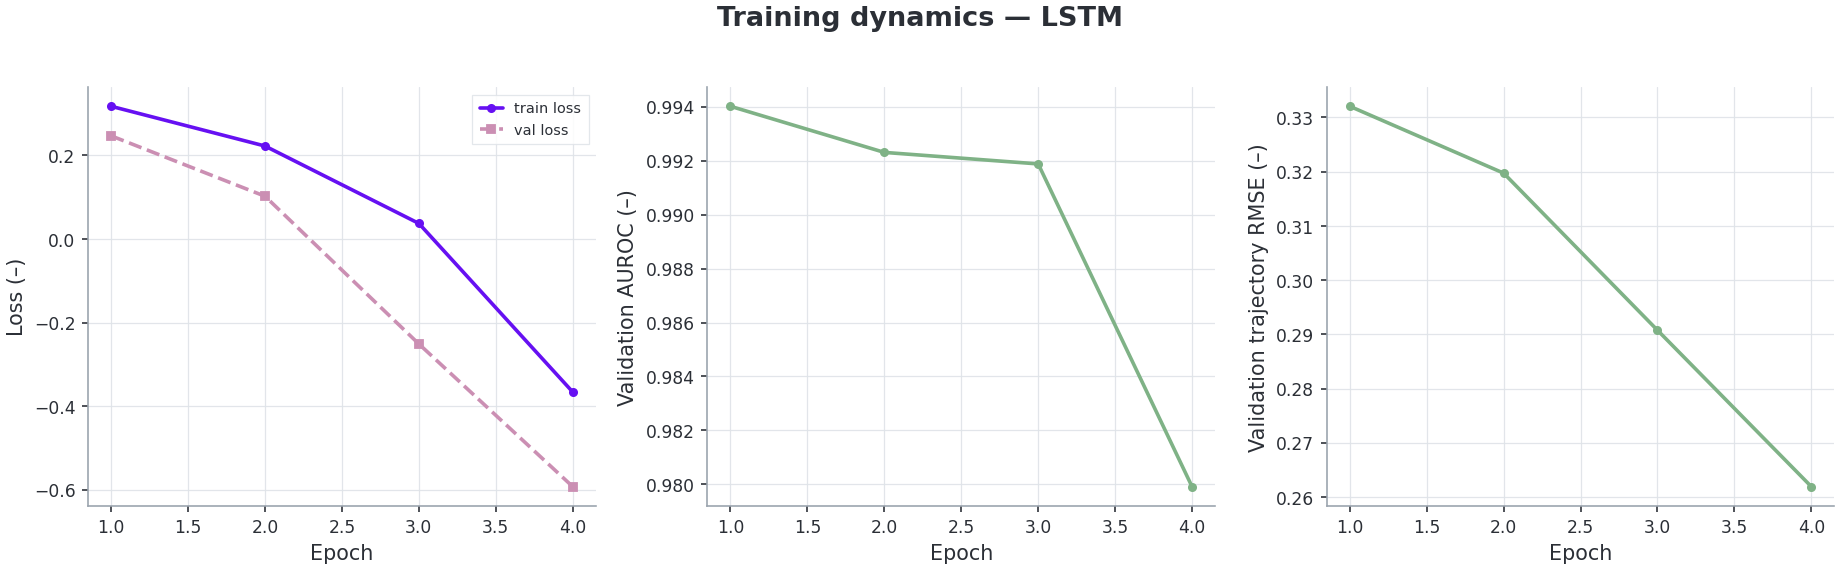

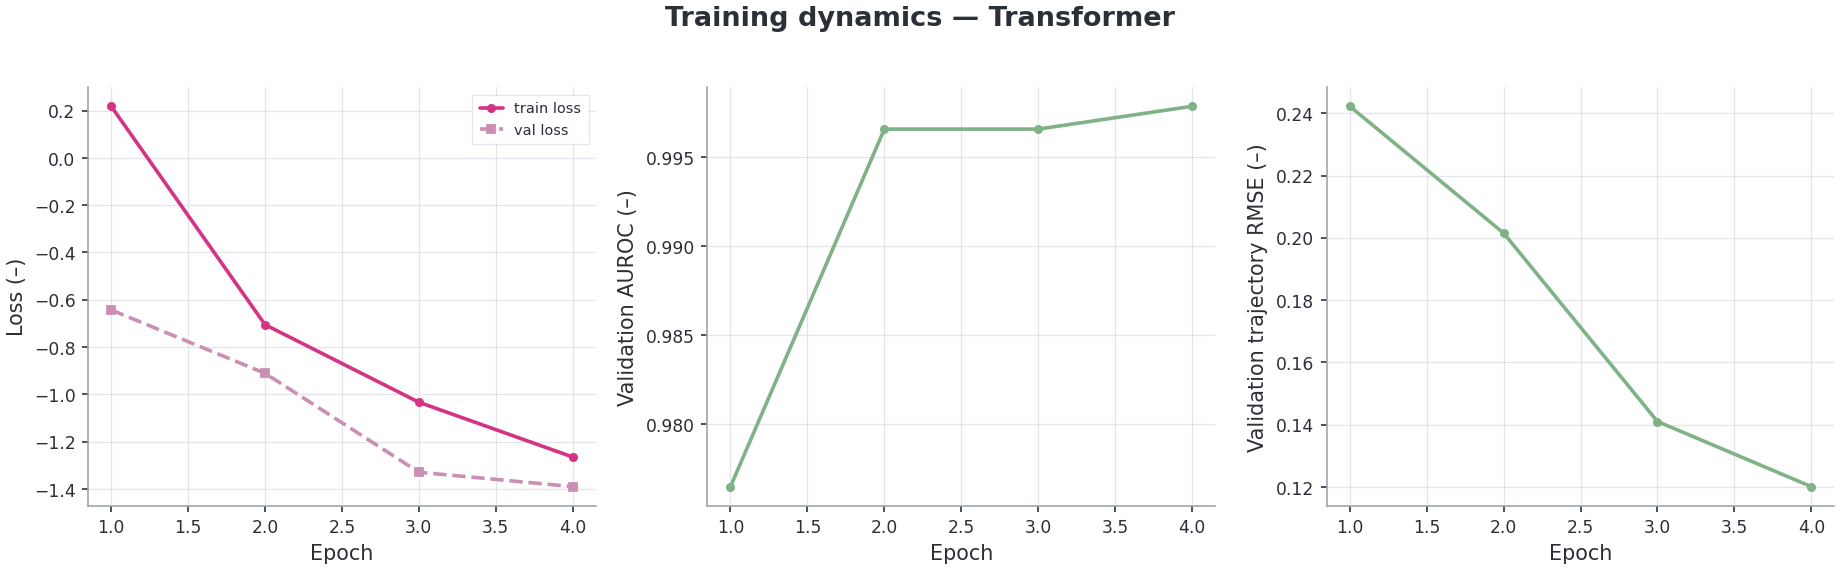

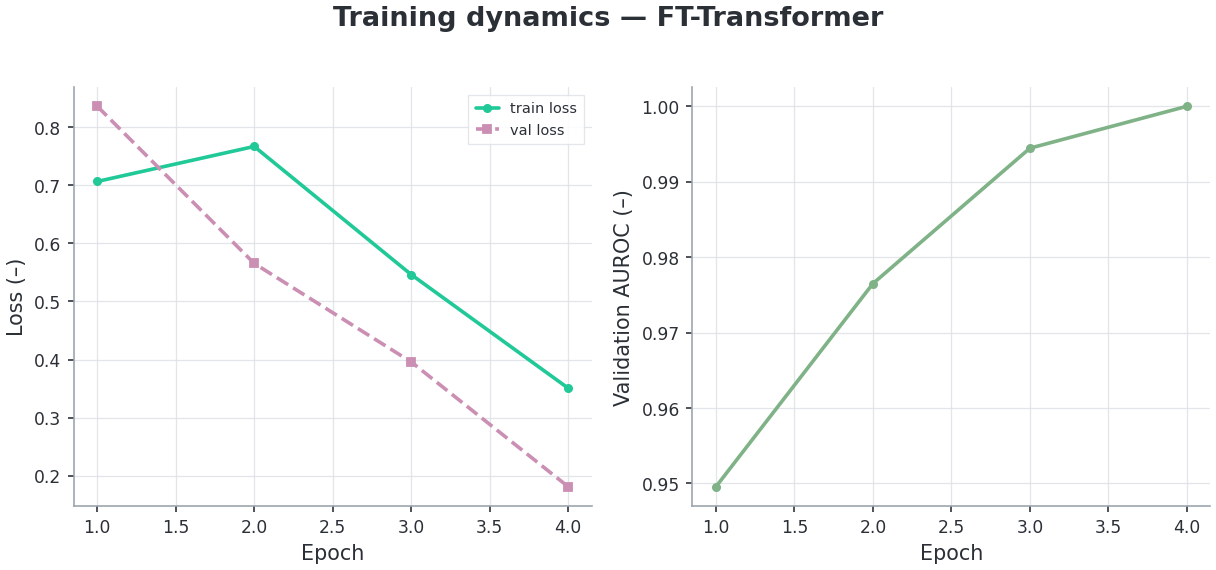

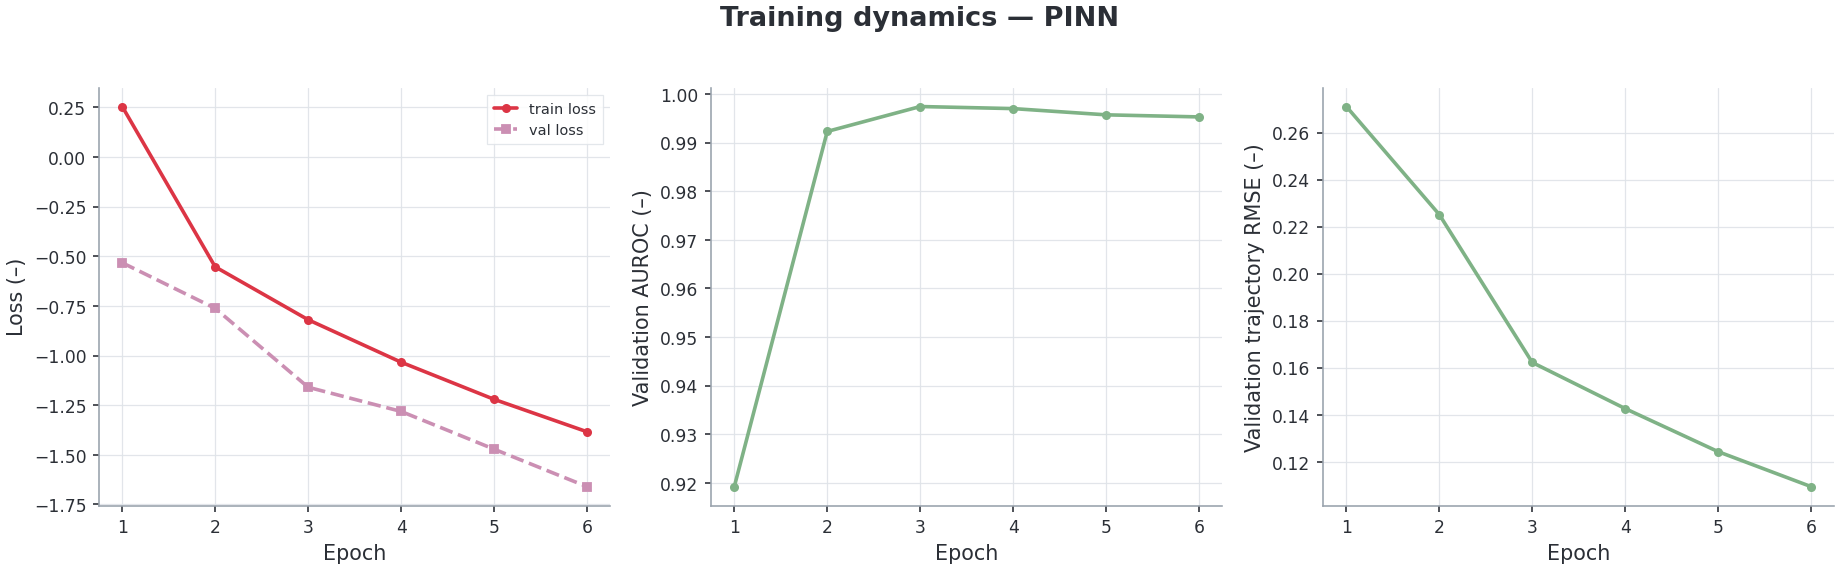

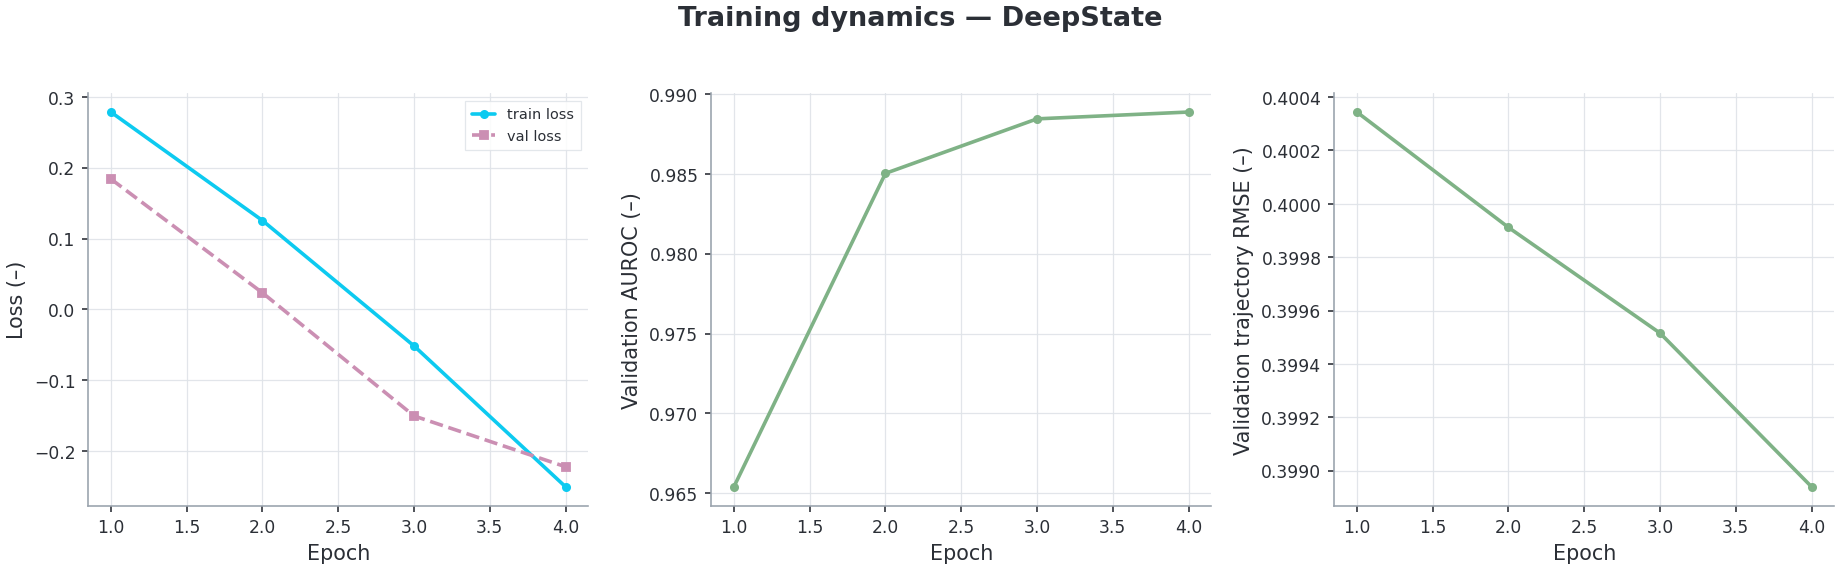

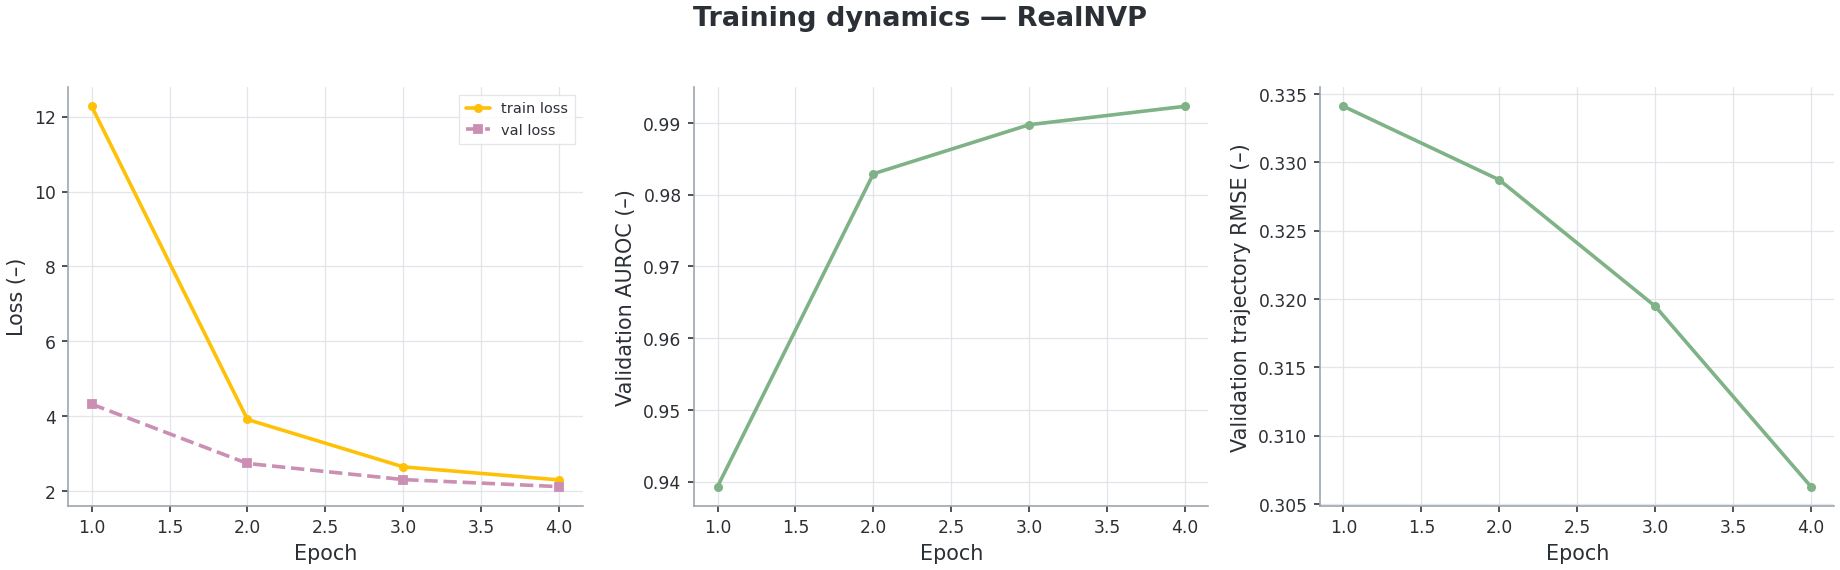

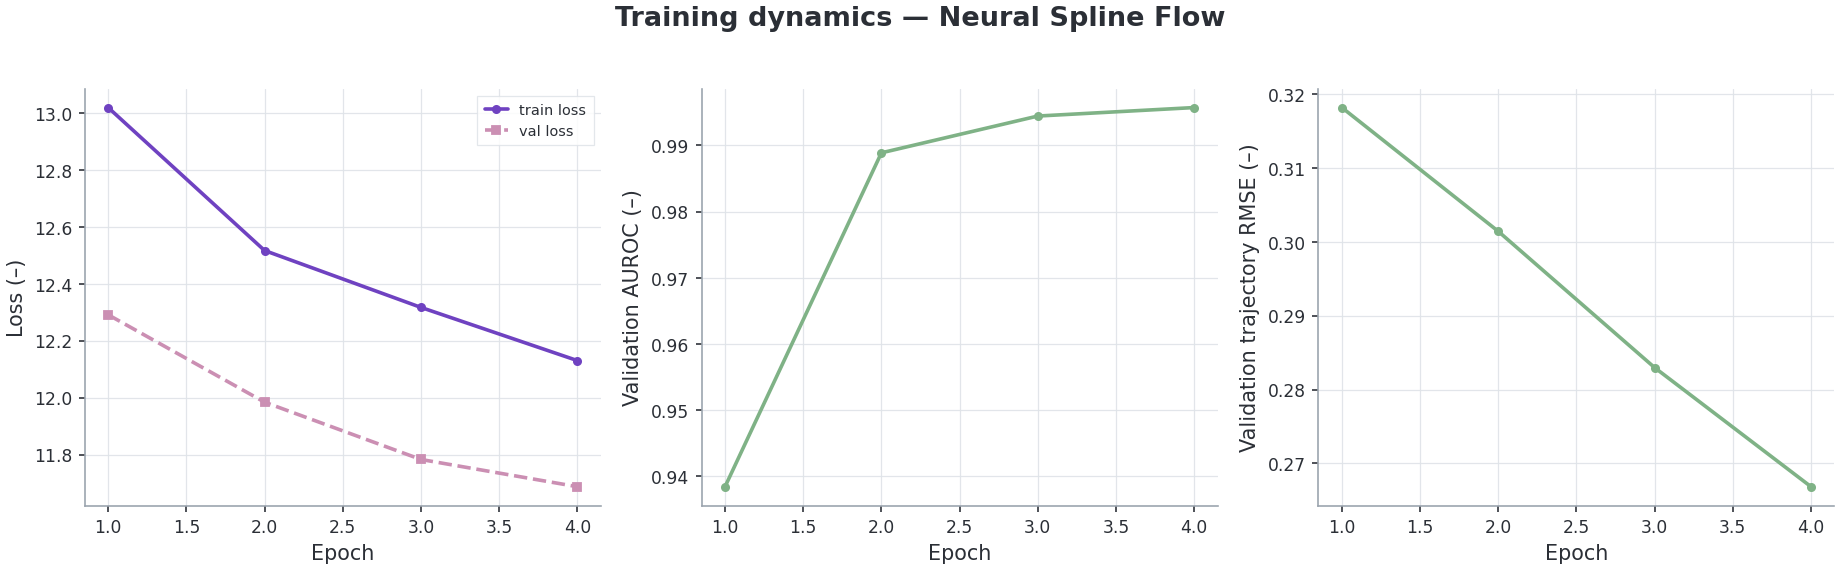

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/catboost
